# BrainCell Network Tutorial

This notebook is a detailed, step-by-step tutorial for `braincell.network`.

The main idea is that network construction has several layers, and each layer stores a different kind of information:

```text
Cell -> Population
Population pairs -> EdgeSet              # cell-cell adjacency only
EdgeSet + ContactMethod -> Projection    # edge-to-synapse contact expansion
Projection -> Connection                 # concrete contact-level sparse table
Connection -> Network.run                # event delivery and traces
```

We inspect each layer directly.  The tutorial cells are real multi-compartment Hodgkin-Huxley cells using the staggered solver; no custom toy solver is used.  Topology-only sections use larger 10-by-10 examples where random graphs are easier to see, while runtime sections keep the population size modest so the notebook stays practical.

Network v1 uses one-dimensional population indexing, so examples use `pop_size=(N,)`.  Multidimensional `Cell.pop_size` can exist at the cell layer, but flat network indexing is the supported network mode here.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import brainstate
import matplotlib.pyplot as plt
import numpy as np

import braincell
import braincell.mech as mech
import brainunit as u
from braincell import Branch, CVPerBranch, Cell, Morphology
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)

print("braincell version:", braincell.__version__)
print("repo_root:", repo_root)


braincell version: 0.1.0
repo_root: /home/swl/braincell


## 0. A tiny soma+dendrite HH cell

The network API works with normal `Cell` objects.  The helpers below build a compact but real HH cell:

- morphology: one soma and one dendrite,
- solver: `solver="staggered"`,
- membrane: `SodiumFixed`, `PotassiumFixed`, `Na_HH1952`, `K_HH1952`, and `IL`,
- presynaptic cell: receives brief current clamps and spikes through HH dynamics,
- postsynaptic cell: receives network events through normal `ExpSyn` and optionally `Exp2Syn` pools.

When `two_targets=True`, each named synapse pool has two local targets: one on the soma and one on the dendrite.  Later, `synapse_index=0` and `synapse_index=1` refer to those local targets.


In [2]:
def build_demo_morphology() -> Morphology:
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    dend = Branch.from_lengths(
        lengths=[80.0] * u.um,
        radii=[2.0, 1.0] * u.um,
        type="basal_dendrite",
    )
    tree = Morphology.from_root(soma, name="soma")
    tree.soma.dend = dend
    return tree


def add_hh_membrane(cell: Cell) -> None:
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * (u.uF / u.cm**2),
            axial_resistivity=100.0 * (u.ohm * u.cm),
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
        mech.Channel("K_HH1952", g_max=36.0 * (u.mS / u.cm**2)),
        mech.Channel("IL", g_max=0.3 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    )


def pulse_protocol(size: int) -> tuple[mech.CurrentClamp, mech.CurrentClamp]:
    base_delays = np.asarray([5.0, 5.2, 5.4, 5.6], dtype=float)
    input_delays = base_delays[np.arange(size) % len(base_delays)]
    amplitudes = u.Quantity(1.0 + 0.02 * np.arange(size, dtype=float), u.nA)

    return (
        mech.CurrentClamp(
            delay=u.Quantity(input_delays, u.ms),
            durations=0.1 * u.ms,
            amplitudes=amplitudes,
        ),
        mech.CurrentClamp(
            delay=u.Quantity(input_delays + 22.0, u.ms),
            durations=0.1 * u.ms,
            amplitudes=amplitudes,
        ),
    )


def build_pre_cell(size: int = 3) -> Cell:
    cell = Cell(
        build_demo_morphology(),
        cv_policy=CVPerBranch(),
        pop_size=(size,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        solver="staggered",
        name="pre",
    )
    add_hh_membrane(cell)
    cell.place(at("soma", 0.5), *pulse_protocol(size=size))
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    return cell


def build_post_cell(
    size: int = 3,
    *,
    two_targets: bool = False,
    synapses: tuple[str, ...] = ("exp",),
) -> Cell:
    cell = Cell(
        build_demo_morphology(),
        cv_policy=CVPerBranch(),
        pop_size=(size,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        solver="staggered",
        name="post",
    )
    add_hh_membrane(cell)

    target = at("soma", 0.5) | at(1, 0.5) if two_targets else at("soma", 0.5)
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))

    if "exp" in synapses:
        cell.place(target, mech.MechanismProbe(name="g_exp", mechanism="exp", field="g"))
        cell.place(
            target,
            mech.Synapse(
                "ExpSyn",
                tau=2.0 * u.ms,
                e=0.0 * u.mV,
                weight=1.0 * u.uS,
                name="exp",
            ),
        )
    if "exp2" in synapses:
        cell.place(target, mech.MechanismProbe(name="g_exp2", mechanism="exp2", field="g"))
        cell.place(
            target,
            mech.Synapse(
                "Exp2Syn",
                tau1=0.5 * u.ms,
                tau2=5.0 * u.ms,
                e=0.0 * u.mV,
                weight=1.0 * u.uS,
                name="exp2",
            ),
        )
    return cell


## Helper functions for inspection

A network tutorial should show intermediate objects, not just final traces.  The following helpers print compact tables and draw small topology matrices.

In [3]:
def edge_table(edge_set, *, max_rows: int | None = None):
    rows = [
        {"edge_id": idx, "pre": int(pre), "post": int(post)}
        for idx, (pre, post) in enumerate(zip(edge_set.pre_index, edge_set.post_index))
    ]
    print(f"EdgeSet {edge_set.name!r}: {edge_set.pre_population} -> {edge_set.post_population}")
    print("  n_edge:", edge_set.n_edge)
    shown = rows if max_rows is None else rows[:max_rows]
    for row in shown:
        print(f"  edge {row['edge_id']:>2}: pre[{row['pre']}] -> post[{row['post']}]")
    if max_rows is not None and len(rows) > max_rows:
        print(f"  ... {len(rows) - max_rows} more edges")
    return rows


def adjacency_matrix(edge_set, *, n_pre: int, n_post: int):
    mat = np.zeros((n_pre, n_post), dtype=int)
    for pre, post in zip(edge_set.pre_index, edge_set.post_index):
        mat[int(pre), int(post)] += 1
    return mat


def _network_matrix_cmap():
    from matplotlib.colors import LinearSegmentedColormap

    colors = [
        "#fff7ed",
        "#ffedd5",
        "#fed7aa",
        "#fdba74",
        "#fb923c",
        "#ea580c",
        "#9a3412",
    ]
    return LinearSegmentedColormap.from_list("network_orange", colors, N=256)


def plot_count_matrix(
    mat,
    *,
    title: str,
    xlabel: str,
    ylabel: str,
    colorbar_label: str,
):
    mat = np.asarray(mat, dtype=int)
    n_row, n_col = mat.shape
    vmax = max(1, int(mat.max(initial=0)))
    fig_width = max(3.8, 0.40 * n_col + 1.7)
    fig_height = max(3.2, 0.36 * n_row + 1.3)
    cmap = _network_matrix_cmap()

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_facecolor("#f3f4f6")
    image = ax.imshow(mat, cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest")

    ax.set_title(title, fontweight="bold", fontsize=11, pad=12)
    ax.set_xlabel(xlabel, fontsize=9, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=9, labelpad=8)
    ax.set_xticks(np.arange(n_col))
    ax.set_yticks(np.arange(n_row))
    ax.set_xticks(np.arange(-0.5, n_col, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_row, 1), minor=True)
    ax.grid(which="minor", color="#d1d5db", linewidth=0.6, alpha=0.85)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", labelsize=7)

    if n_row * n_col <= 120:
        norm = image.norm
        for row in range(n_row):
            for col in range(n_col):
                value = mat[row, col]
                if value:
                    rgba = cmap(norm(value))
                    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                    text_color = "white" if luminance < 0.55 else "black"
                    ax.text(
                        col,
                        row,
                        str(int(value)),
                        ha="center",
                        va="center",
                        color=text_color,
                        fontsize=8,
                        fontweight="semibold",
                    )

    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, aspect=30)
    cbar.set_label(colorbar_label, fontsize=8, labelpad=6)
    cbar.ax.tick_params(labelsize=7)
    fig.tight_layout()
    plt.show()
    return mat


def plot_adjacency(edge_set, *, n_pre: int, n_post: int, title: str | None = None):
    mat = adjacency_matrix(edge_set, n_pre=n_pre, n_post=n_post)
    return plot_count_matrix(
        mat,
        title=title or edge_set.name,
        xlabel="post cell id",
        ylabel="pre cell id",
        colorbar_label="edge count",
    )


def _as_1d(value, *, length, unit=None):
    if value is None:
        return [None] * length
    if hasattr(value, "to_decimal"):
        arr = np.asarray(value.to_decimal(unit or value.unit), dtype=float)
    else:
        arr = np.asarray(value)
    if arr.shape == ():
        arr = np.broadcast_to(arr, (length,)).copy()
    return arr.reshape(-1).tolist()


def connection_table(conn):
    weights = _as_1d(conn.weight, length=conn.n_contact, unit=u.uS)
    delays = _as_1d(conn.delay, length=conn.n_contact, unit=u.ms)
    print(f"Connection: {conn.pre_population} -> {conn.post_population}, synapse={conn.synapse!r}")
    print("  n_contact:", conn.n_contact)
    print("  contact_id | pre | post | synapse_index | weight_uS | delay_ms")
    for idx in range(conn.n_contact):
        print(
            f"  {idx:>10} | {int(conn.pre_index[idx]):>3} | {int(conn.post_index[idx]):>4} | "
            f"{int(conn.synapse_index[idx]):>13} | {weights[idx]!s:>9} | {delays[idx]!s:>8}"
        )
    return {
        "pre": conn.pre_index,
        "post": conn.post_index,
        "synapse_index": conn.synapse_index,
        "weight_uS": weights,
        "delay_ms": delays,
    }


def projection_to_connection(projection, edge_set, *, pre_size, post_size, pool_size):
    print(f"Projection {projection.name!r}: edges={projection.edge_set_name!r}, synapse={projection.synapse!r}")
    conn = projection.to_connections(edge_set, pre_size=pre_size, post_size=post_size, pool_size=pool_size)[0]
    connection_table(conn)
    return conn


def plot_synapse_targets(conn, *, post_size: int, pool_size: int, title: str):
    mat = np.zeros((post_size, pool_size), dtype=int)
    for post, syn in zip(conn.post_index, conn.synapse_index):
        mat[int(post), int(syn)] += 1
    return plot_count_matrix(
        mat,
        title=title,
        xlabel="local synapse target id",
        ylabel="post cell id",
        colorbar_label="contact count",
    )


def trace_to_2d(value, unit):
    arr = np.asarray(value.to_decimal(unit), dtype=float)
    return arr.reshape((arr.shape[0], -1))


def spike_to_2d(result, population: str):
    spikes = np.asarray(result.spikes[population], dtype=bool)
    return spikes.reshape((spikes.shape[0], -1))


def first_spike_times(result, population: str):
    time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
    spikes = spike_to_2d(result, population)
    first = []
    counts = spikes.sum(axis=0).astype(int)
    for idx in range(spikes.shape[1]):
        steps = np.flatnonzero(spikes[:, idx])
        first.append(None if steps.size == 0 else float(time_ms[steps[0]]))
    print(f"{population} first spike times ms:", first)
    print(f"{population} spike counts:", counts.tolist())
    return first, counts


def plot_voltage_small_multiples(result, population: str, *, title: str, unit=u.mV, max_columns: int = 4):
    time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
    voltage = trace_to_2d(result.traces[population]["v"], unit)
    n_trace = voltage.shape[1]
    n_col = min(max_columns, n_trace)
    n_row = int(np.ceil(n_trace / n_col))
    fig, axes = plt.subplots(n_row, n_col, figsize=(3.0 * n_col, 2.0 * n_row), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(-1)
    for idx in range(n_trace):
        ax = axes[idx]
        ax.plot(time_ms, voltage[:, idx], color="tab:blue", linewidth=1.1)
        ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.35)
        ax.set_title(f"{population}[{idx}]", fontsize=9)
        ax.grid(True, alpha=0.25)
    for ax in axes[n_trace:]:
        ax.axis("off")
    for ax in axes[:n_trace:n_col]:
        ax.set_ylabel("v (mV)")
    for ax in axes[max(0, (n_row - 1) * n_col):n_trace]:
        ax.set_xlabel("time (ms)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return voltage


def plot_spike_raster(result, population: str, *, title: str):
    time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
    spikes = spike_to_2d(result, population)
    fig, ax = plt.subplots(figsize=(7.0, 2.8))
    for cell_id in range(spikes.shape[1]):
        spike_times = time_ms[np.flatnonzero(spikes[:, cell_id])]
        if spike_times.size:
            ax.scatter(spike_times, np.full(spike_times.shape, cell_id), s=28, marker="|", color="black")
    ax.set_title(title)
    ax.set_xlabel("time (ms)")
    ax.set_ylabel(f"{population} cell id")
    ax.set_yticks(np.arange(spikes.shape[1]))
    ax.grid(True, axis="x", alpha=0.25)
    plt.show()
    return spikes


def plot_conductance(result, population: str, trace_names=("g_exp", "g_exp2"), *, title: str):
    present = [name for name in trace_names if population in result.traces and name in result.traces[population]]
    if not present:
        return {}
    time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
    fig, axes = plt.subplots(len(present), 1, figsize=(7.0, 2.5 * len(present)), sharex=True)
    axes = np.atleast_1d(axes)
    traces = {}
    for ax, trace_name in zip(axes, present):
        g = trace_to_2d(result.traces[population][trace_name], u.uS)
        traces[trace_name] = g
        print(f"  {population}.{trace_name} shape:", result.traces[population][trace_name].shape)
        print(f"  {population}.{trace_name} max uS:", float(np.max(g)))
        for idx in range(g.shape[1]):
            ax.plot(time_ms, g[:, idx], linewidth=1.1, label=f"target {idx}")
        ax.set_title(f"{title}: {trace_name}")
        ax.set_ylabel("conductance (uS)")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, ncol=min(4, g.shape[1]))
    axes[-1].set_xlabel("time (ms)")
    plt.show()
    return traces


def run_and_plot(net, *, title: str, duration=30.0 * u.ms, spike_recording="population"):
    result = net.run(
        dt=0.1 * u.ms,
        duration=duration,
        event_backend="scatter",
        spike_recording=spike_recording,
    )
    print(title)
    print("  result.time shape:", result.time.shape)
    print("  trace keys:", {pop: tuple(traces) for pop, traces in result.traces.items()})
    print("  spike shapes:", {pop: np.asarray(value).shape for pop, value in result.spikes.items()})
    for population in result.traces:
        if "v" in result.traces[population]:
            voltage = trace_to_2d(result.traces[population]["v"], u.mV)
            print(f"  {population}.v range mV:", (float(np.min(voltage)), float(np.max(voltage))))
            plot_voltage_small_multiples(result, population, title=f"{title}: {population} membrane voltage")
            if population in result.spikes:
                first_spike_times(result, population)
                plot_spike_raster(result, population, title=f"{title}: {population} spike raster")
    for population in result.traces:
        plot_conductance(result, population, title=title)
    return result


## 1. Population: add named cell groups

`add_population(name, cell)` is intentionally simple.  It wraps a homogeneous `Cell` and gives it a network-level name.  The important thing to inspect is that `net.populations` is just a named registry, and `Population.size` comes from `cell.pop_size`.

In [4]:
pop_net = braincell.Network(name="population_demo")
pre = build_pre_cell(size=3)
post = build_post_cell(size=2)

E = pop_net.add_population("E", pre)
I = pop_net.add_population("I", post)

print(pop_net)
print("Returned Population objects:")
print("  E:", E)
print("  I:", I)
print("Population names from net:", tuple(pop_net.populations))
print("Population sizes:", {name: pop.size for name, pop in pop_net.populations.items()})

Network(name='population_demo', populations=2, edge_sets=0, projections=0, connections=0)
  populations:
    E: size=3, cell=Cell, initialized=False
    I: size=2, cell=Cell, initialized=False
  edge_sets:
    <none>
  projections:
    <none>
  direct connections:
    <none>
Returned Population objects:
  E: Population(name='E', size=3, cell=Cell, initialized=False)
  I: Population(name='I', size=2, cell=Cell, initialized=False)
Population names from net: ('E', 'I')
Population sizes: {'E': 3, 'I': 2}


## 2. EdgeSet: cell-cell adjacency only

An `EdgeSet` answers only one question:

> Which presynaptic cell id connects to which postsynaptic cell id?

It does **not** store synapse name, local synapse target, weight, or delay.  That makes edge sets reusable: the same adjacency can drive several projections later.

### 2.1 Explicit sparse pairs

`pairs(...)` is the most direct builder.  Each tuple is one row in the sparse adjacency table.

Network(name='edge_demo', populations=2, edge_sets=1, projections=0, connections=0)
  populations:
    E: size=4, cell=Cell, initialized=False
    I: size=3, cell=Cell, initialized=False
  edge_sets:
    pairs_edges: E -> I, n_edge=4
  projections:
    <none>
  direct connections:
    <none>
EdgeSet 'pairs_edges': E -> I
  n_edge: 4
  edge  0: pre[0] -> post[0]
  edge  1: pre[0] -> post[2]
  edge  2: pre[2] -> post[1]
  edge  3: pre[3] -> post[2]


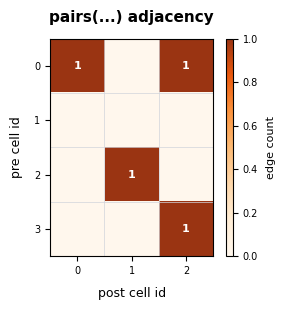

array([[1, 0, 1],
       [0, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [5]:
edge_net = braincell.Network(name="edge_demo")
edge_net.add_population("E", build_pre_cell(size=4))
edge_net.add_population("I", build_post_cell(size=3))

pairs_edges = edge_net.add_edges(
    name="pairs_edges",
    pre="E",
    post="I",
    method=braincell.network.pairs([(0, 0), (0, 2), (2, 1), (3, 2)]),
)
print(edge_net)
edge_table(pairs_edges)
plot_adjacency(pairs_edges, n_pre=4, n_post=3, title="pairs(...) adjacency")

### 2.2 Dense adjacency matrix

`dense(...)` converts nonzero matrix entries into sparse pairs.  Matrix rows are presynaptic ids and columns are postsynaptic ids.

Input dense matrix:
 [[0 1 0]
 [1 0 1]
 [0 0 0]
 [0 1 1]]
EdgeSet 'dense_edges': E -> I
  n_edge: 5
  edge  0: pre[0] -> post[1]
  edge  1: pre[1] -> post[0]
  edge  2: pre[1] -> post[2]
  edge  3: pre[3] -> post[1]
  edge  4: pre[3] -> post[2]


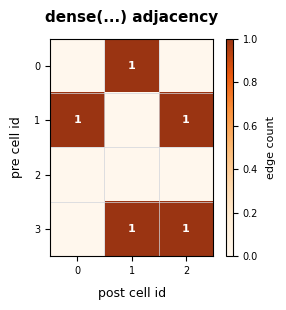

array([[0, 1, 0],
       [1, 0, 1],
       [0, 0, 0],
       [0, 1, 1]])

In [6]:
dense_matrix = np.asarray(
    [
        [0, 1, 0],
        [1, 0, 1],
        [0, 0, 0],
        [0, 1, 1],
    ],
    dtype=int,
)
print("Input dense matrix:\n", dense_matrix)

dense_edges = edge_net.add_edges(
    name="dense_edges",
    pre="E",
    post="I",
    method=braincell.network.dense(dense_matrix),
)
edge_table(dense_edges)
plot_adjacency(dense_edges, n_pre=4, n_post=3, title="dense(...) adjacency")

### 2.3 `all_pairs`: fully connect selected subsets

`all_pairs(pre_indices=[...], post_indices=[...])` builds a Cartesian product.  It is useful for fully connecting selected presynaptic and postsynaptic subsets.

EdgeSet 'all_pair_edges': E -> I
  n_edge: 4
  edge  0: pre[0] -> post[1]
  edge  1: pre[0] -> post[2]
  edge  2: pre[2] -> post[1]
  edge  3: pre[2] -> post[2]


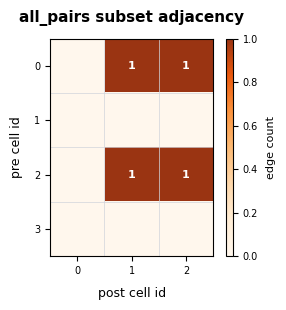

array([[0, 1, 1],
       [0, 0, 0],
       [0, 1, 1],
       [0, 0, 0]])

In [7]:
all_pair_edges = edge_net.add_edges(
    name="all_pair_edges",
    pre="E",
    post="I",
    method=braincell.network.all_pairs(pre_indices=[0, 2], post_indices=[1, 2]),
)
edge_table(all_pair_edges)
plot_adjacency(all_pair_edges, n_pre=4, n_post=3, title="all_pairs subset adjacency")

### 2.4 Probability graph

`probability(p=..., seed=...)` samples a Bernoulli graph at construction time.  With the same seed, the same edge table is produced.

EdgeSet 'probability_a': E -> I
  n_edge: 18
  edge  0: pre[0] -> post[4]
  edge  1: pre[0] -> post[7]
  edge  2: pre[0] -> post[8]
  edge  3: pre[1] -> post[9]
  edge  4: pre[2] -> post[3]
  edge  5: pre[2] -> post[9]
  edge  6: pre[3] -> post[1]
  edge  7: pre[3] -> post[4]
  edge  8: pre[3] -> post[8]
  edge  9: pre[4] -> post[8]
  edge 10: pre[5] -> post[0]
  edge 11: pre[6] -> post[4]
  edge 12: pre[6] -> post[9]
  edge 13: pre[7] -> post[9]
  edge 14: pre[8] -> post[8]
  edge 15: pre[9] -> post[5]
  edge 16: pre[9] -> post[7]
  edge 17: pre[9] -> post[9]
same seed gives same pre_index: True
same seed gives same post_index: True


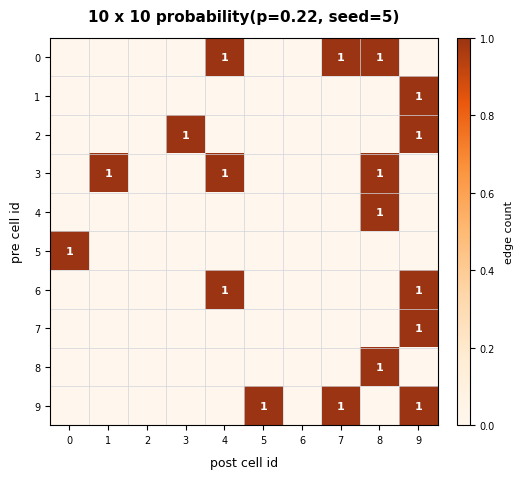

array([[0, 0, 0, 0, 1, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 1]])

In [8]:
large_n_pre = 10
large_n_post = 10
prob_net = braincell.Network(name="probability_edge_demo")
prob_net.add_population("E", build_pre_cell(size=large_n_pre))
prob_net.add_population("I", build_post_cell(size=large_n_post))
prob_a = prob_net.add_edges(
    name="probability_a",
    pre="E",
    post="I",
    method=braincell.network.probability(p=0.22, seed=5),
)
prob_b = prob_net.add_edges(
    name="probability_b",
    pre="E",
    post="I",
    method=braincell.network.probability(p=0.22, seed=5),
)
edge_table(prob_a, max_rows=25)
print("same seed gives same pre_index:", np.array_equal(prob_a.pre_index, prob_b.pre_index))
print("same seed gives same post_index:", np.array_equal(prob_a.post_index, prob_b.post_index))
plot_adjacency(prob_a, n_pre=large_n_pre, n_post=large_n_post, title="10 x 10 probability(p=0.22, seed=5)")


### 2.5 Custom edge method

A custom edge method is any callable with signature `method(*, n_pre, n_post)` returning `(pre_index, post_index)`.  The network layer handles dtype and bounds validation after the callable returns.

EdgeSet 'custom_ring': E -> I
  n_edge: 10
  edge  0: pre[0] -> post[1]
  edge  1: pre[1] -> post[2]
  edge  2: pre[2] -> post[3]
  edge  3: pre[3] -> post[4]
  edge  4: pre[4] -> post[5]
  edge  5: pre[5] -> post[6]
  edge  6: pre[6] -> post[7]
  edge  7: pre[7] -> post[8]
  edge  8: pre[8] -> post[9]
  edge  9: pre[9] -> post[0]


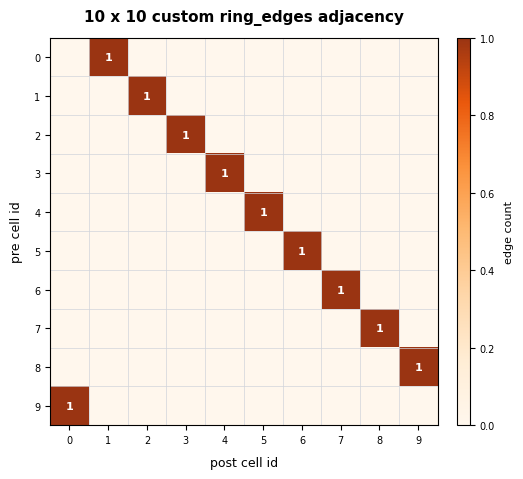

array([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [9]:
def ring_edges(*, n_pre: int, n_post: int):
    pre_index = np.arange(n_pre, dtype=np.int32)
    post_index = (pre_index + 1) % n_post
    return pre_index, post_index


custom_edge_net = braincell.Network(name="custom_edge_demo")
custom_edge_net.add_population("E", build_pre_cell(size=10))
custom_edge_net.add_population("I", build_post_cell(size=10))
ring = custom_edge_net.add_edges(
    name="custom_ring",
    pre="E",
    post="I",
    method=ring_edges,
)
edge_table(ring)
plot_adjacency(ring, n_pre=10, n_post=10, title="10 x 10 custom ring_edges adjacency")


## 3. Projection: refine edges into synaptic contacts

An edge says `pre cell -> post cell`.  A projection decides how each edge becomes one or more synaptic contacts on one named postsynaptic synapse pool.

For this section, the postsynaptic cell has two local `ExpSyn` targets named `"exp"`.  Therefore the valid local target ids are `synapse_index=0` and `synapse_index=1`.  Later, the same machinery is reused for a double-exponential `Exp2Syn` pool named `"exp2"`.


The reusable edge table:
EdgeSet 'E_to_I': E -> I
  n_edge: 3
  edge  0: pre[0] -> post[1]
  edge  1: pre[1] -> post[1]
  edge  2: pre[2] -> post[2]


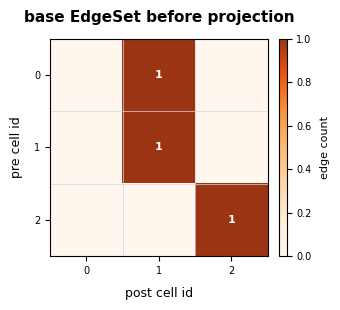

array([[0, 1, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [10]:
base_edges = braincell.network.EdgeSet("E_to_I", "E", "I", [0, 1, 2], [1, 1, 2])
print("The reusable edge table:")
edge_table(base_edges)
plot_adjacency(base_edges, n_pre=3, n_post=3, title="base EdgeSet before projection")

### 3.1 Default-style `per_edge(number=1)`

`per_edge` treats every edge independently.  With `number=1`, each edge chooses one local synapse target.  Because each edge produces one contact, `n_contact == n_edge`.

Projection 'per_edge_one': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 3
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |       0.1 |      0.0
           1 |   1 |    1 |             1 |       0.1 |      0.0
           2 |   2 |    2 |             1 |       0.1 |      0.0


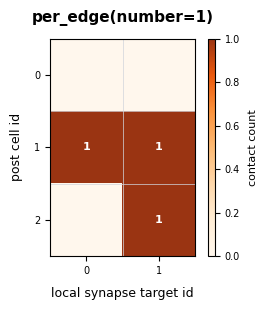

array([[0, 0],
       [1, 1],
       [0, 1]])

In [11]:
per_edge_one = braincell.network.Projection(
    name="per_edge_one",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.per_edge(number=1, replace=True, seed=1),
    weight=0.1 * u.uS,
)
conn = projection_to_connection(per_edge_one, base_edges, pre_size=3, post_size=3, pool_size=2)
plot_synapse_targets(conn, post_size=3, pool_size=2, title="per_edge(number=1)")

### 3.2 `per_edge(number=2, replace=False)`

Now each edge expands into two contacts.  Because `replace=False` and the pool has two targets, each edge uses both local targets exactly once.

A per-edge weight with shape `(n_edge,)` is repeated over that edge's expanded contacts.

Projection 'per_edge_two': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 6
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |       0.1 |      0.0
           1 |   0 |    1 |             1 |       0.1 |      0.0
           2 |   1 |    1 |             0 |       0.2 |      0.0
           3 |   1 |    1 |             1 |       0.2 |      0.0
           4 |   2 |    2 |             1 |       0.3 |      0.0
           5 |   2 |    2 |             0 |       0.3 |      0.0


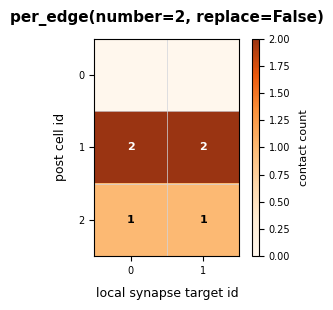

array([[0, 0],
       [2, 2],
       [1, 1]])

In [12]:
per_edge_two = braincell.network.Projection(
    name="per_edge_two",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.per_edge(number=2, replace=False, seed=1),
    weight=[0.1, 0.2, 0.3] * u.uS,
)
conn = projection_to_connection(per_edge_two, base_edges, pre_size=3, post_size=3, pool_size=2)
plot_synapse_targets(conn, post_size=3, pool_size=2, title="per_edge(number=2, replace=False)")

### 3.3 `by_post`: coordinate contacts landing on the same post cell

`by_post` groups incoming contacts by postsynaptic cell before choosing local targets.  This is useful when local synapse target reuse should be controlled at the post-cell level, not edge-by-edge.

Projection 'by_post_projection': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 3
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             1 |       0.2 |      0.0
           1 |   1 |    1 |             0 |       0.2 |      0.0
           2 |   2 |    2 |             0 |       0.2 |      0.0


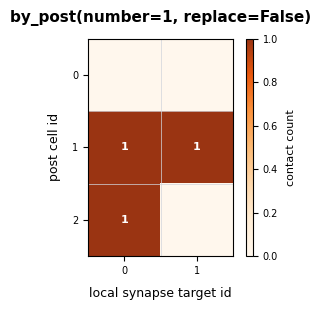

array([[0, 0],
       [1, 1],
       [1, 0]])

In [13]:
by_post_projection = braincell.network.Projection(
    name="by_post_projection",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.by_post(number=1, replace=False, seed=2),
    weight=0.2 * u.uS,
)
conn = projection_to_connection(by_post_projection, base_edges, pre_size=3, post_size=3, pool_size=2)
plot_synapse_targets(conn, post_size=3, pool_size=2, title="by_post(number=1, replace=False)")

### 3.4 `explicit_contacts`: provide the contact table directly

`explicit_contacts(source_edge=..., synapse_index=...)` is the most direct projection method.

- `source_edge[k]` says which edge row contact `k` came from.
- `synapse_index[k]` says which local synapse target receives contact `k`.

Here edge 0 produces two contacts, edge 1 produces one contact, and edge 2 produces one contact.

Projection 'explicit_projection': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 4
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |       0.1 |      0.0
           1 |   0 |    1 |             1 |       0.2 |      0.0
           2 |   1 |    1 |             1 |       0.3 |      0.0
           3 |   2 |    2 |             0 |       0.4 |      0.0


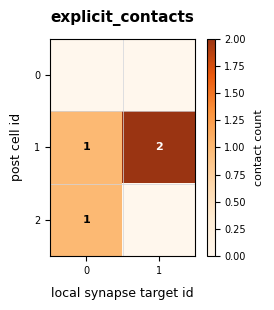

array([[0, 0],
       [1, 2],
       [1, 0]])

In [14]:
explicit_projection = braincell.network.Projection(
    name="explicit_projection",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.explicit_contacts(
        source_edge=[0, 0, 1, 2],
        synapse_index=[0, 1, 1, 0],
    ),
    weight=[0.1, 0.2, 0.3, 0.4] * u.uS,
)
conn = projection_to_connection(explicit_projection, base_edges, pre_size=3, post_size=3, pool_size=2)
plot_synapse_targets(conn, post_size=3, pool_size=2, title="explicit_contacts")

### 3.5 Custom contact method

A custom contact method receives `ProjectionEdgeContext` and returns `ContactTable`.  This example duplicates contacts for edges whose presynaptic cell id is even.

Projection 'custom_contacts': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 5
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |      0.25 |      0.0
           1 |   0 |    1 |             1 |      0.25 |      0.0
           2 |   1 |    1 |             0 |      0.25 |      0.0
           3 |   2 |    2 |             0 |      0.25 |      0.0
           4 |   2 |    2 |             1 |      0.25 |      0.0


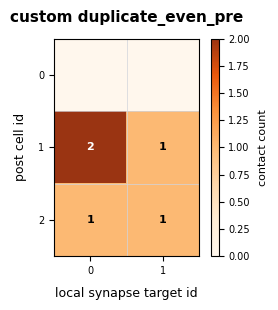

array([[0, 0],
       [2, 1],
       [1, 1]])

In [15]:
def duplicate_even_pre(ctx):
    source_edge = []
    synapse_index = []
    for local_edge, pre_id in enumerate(ctx.edge_pre_index.tolist()):
        source_edge.append(local_edge)
        synapse_index.append(0)
        if pre_id % 2 == 0:
            source_edge.append(local_edge)
            synapse_index.append(1)
    return braincell.network.ContactTable(source_edge=source_edge, synapse_index=synapse_index)


custom_projection = braincell.network.Projection(
    name="custom_contacts",
    edges="E_to_I",
    synapse="exp",
    method=duplicate_even_pre,
    weight=0.25 * u.uS,
)
conn = projection_to_connection(custom_projection, base_edges, pre_size=3, post_size=3, pool_size=2)
plot_synapse_targets(conn, post_size=3, pool_size=2, title="custom duplicate_even_pre")

## 4. Projection parameters: scalar, per-edge, per-contact, callable

After contacts are generated, projection parameters are resolved onto the contact table.

Accepted forms:

- scalar: one value for every contact,
- shape `(n_edge,)`: one value per selected edge, repeated to contacts from that edge,
- shape `(n_contact,)`: one value per final contact,
- callable: receives `ProjectionContactContext` and returns one of the above.

### 4.1 Scalar weight and delay

In [16]:
scalar_projection = braincell.network.Projection(
    name="scalar_params",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.per_edge(number=2, replace=False, seed=0),
    weight=0.2 * u.uS,
    delay=0.0 * u.ms,
)
projection_to_connection(scalar_projection, base_edges, pre_size=3, post_size=3, pool_size=2)

Projection 'scalar_params': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 6
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |       0.2 |      0.0
           1 |   0 |    1 |             1 |       0.2 |      0.0
           2 |   1 |    1 |             1 |       0.2 |      0.0
           3 |   1 |    1 |             0 |       0.2 |      0.0
           4 |   2 |    2 |             1 |       0.2 |      0.0
           5 |   2 |    2 |             0 |       0.2 |      0.0


Connection(pre_population='E', post_population='I', synapse='exp', n_contact=6)

### 4.2 Per-edge weight

There are three edges and each edge produces two contacts.  The three weight values are repeated according to `source_edge`.

In [17]:
per_edge_weight_projection = braincell.network.Projection(
    name="per_edge_weight",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.per_edge(number=2, replace=False, seed=0),
    weight=[0.1, 0.2, 0.3] * u.uS,
)
projection_to_connection(per_edge_weight_projection, base_edges, pre_size=3, post_size=3, pool_size=2)

Projection 'per_edge_weight': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 6
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |       0.1 |      0.0
           1 |   0 |    1 |             1 |       0.1 |      0.0
           2 |   1 |    1 |             1 |       0.2 |      0.0
           3 |   1 |    1 |             0 |       0.2 |      0.0
           4 |   2 |    2 |             1 |       0.3 |      0.0
           5 |   2 |    2 |             0 |       0.3 |      0.0


Connection(pre_population='E', post_population='I', synapse='exp', n_contact=6)

### 4.3 Per-contact weight

Here the method produces six contacts, so six weights can be supplied directly.

In [18]:
per_contact_weight_projection = braincell.network.Projection(
    name="per_contact_weight",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.per_edge(number=2, replace=False, seed=0),
    weight=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30] * u.uS,
)
projection_to_connection(per_contact_weight_projection, base_edges, pre_size=3, post_size=3, pool_size=2)

Projection 'per_contact_weight': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 6
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |      0.05 |      0.0
           1 |   0 |    1 |             1 |       0.1 |      0.0
           2 |   1 |    1 |             1 |      0.15 |      0.0
           3 |   1 |    1 |             0 |       0.2 |      0.0
           4 |   2 |    2 |             1 |      0.25 |      0.0
           5 |   2 |    2 |             0 |       0.3 |      0.0


Connection(pre_population='E', post_population='I', synapse='exp', n_contact=6)

### 4.4 Callable weight and delay

A callable receives `ProjectionContactContext`, so it can branch on contact-level fields such as `contact_pre_index`, `contact_post_index`, and `synapse_index`.

Projection 'callable_params': edges='E_to_I', synapse='exp'
Connection: E -> I, synapse='exp'
  n_contact: 6
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |     0.001 |      0.2
           1 |   0 |    1 |             1 |    0.0013 |      0.2
           2 |   1 |    1 |             0 |     0.001 |      0.2
           3 |   1 |    1 |             1 |    0.0013 |      0.2
           4 |   2 |    2 |             0 |    0.0015 |      0.0
           5 |   2 |    2 |             1 |    0.0018 |      0.0


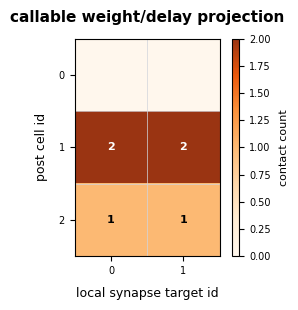

array([[0, 0],
       [2, 2],
       [1, 1]])

In [19]:
def weight_rule(ctx):
    base = np.where(ctx.contact_pre_index == 2, 0.0015, 0.0010)
    target_boost = np.where(ctx.synapse_index == 1, 0.0003, 0.0)
    return (base + target_boost) * u.uS


def delay_rule(ctx):
    return np.where(ctx.contact_post_index == 1, 0.2, 0.0) * u.ms


callable_projection = braincell.network.Projection(
    name="callable_params",
    edges="E_to_I",
    synapse="exp",
    method=braincell.network.per_edge(number=2, replace=False, seed=4),
    weight=weight_rule,
    delay=delay_rule,
)
callable_conn = projection_to_connection(callable_projection, base_edges, pre_size=3, post_size=3, pool_size=2)
plot_synapse_targets(callable_conn, post_size=3, pool_size=2, title="callable weight/delay projection")


## 5. Runtime examples: stimuli and ring propagation

The earlier sections inspected topology and projection expansion.  Runtime behavior is easier to read when we separate it into two examples:

1. different current-clamp amplitudes produce different HH spike responses,
2. a recurrent ring uses synaptic events and delay to pass a spike from one cell to the next.


### 5.1 Different stimuli evoke different HH spikes

This network has one HH population and no synaptic connections.  Each cell receives a different current-clamp amplitude and delay.  The voltage panels show the membrane response per cell, and the spike raster makes the threshold crossings explicit.


Network(name='stimulus_response_demo', populations=1, edge_sets=0, projections=0, connections=0)
  populations:
    S: size=6, cell=Cell, initialized=True
  edge_sets:
    <none>
  projections:
    <none>
  direct connections:
    <none>
stimulus amplitudes nA: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
stimulus delays ms: [5.0, 8.0, 11.0, 14.0, 17.0, 20.0]
S first spike times ms: [None, None, None, 16.8, 18.650000000000002, 21.25]
S spike counts: [0, 0, 0, 1, 1, 1]


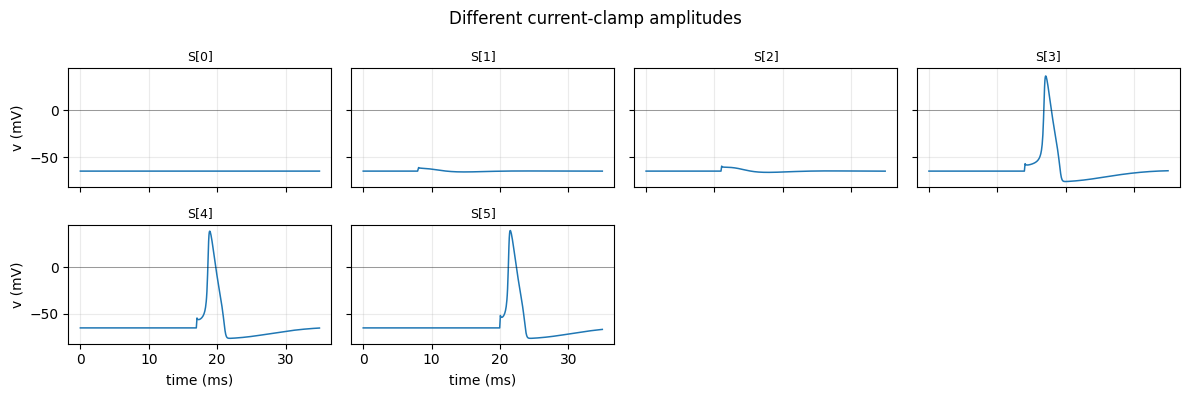

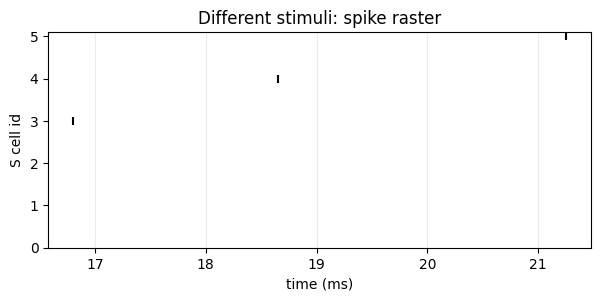

array([[False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       ...,
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False]], shape=(700, 6))

In [20]:
stim_size = 6
stim_amplitudes = np.asarray([0.0, 0.5, 1.0, 1.5, 2.0, 2.5], dtype=float)
stim_delays = np.asarray([5.0, 8.0, 11.0, 14.0, 17.0, 20.0], dtype=float)

stim_cell = Cell(
    build_demo_morphology(),
    cv_policy=CVPerBranch(),
    pop_size=(stim_size,),
    V_init=-65.0 * u.mV,
    V_th=0.0 * u.mV,
    solver="staggered",
    name="stimulus_demo",
)
add_hh_membrane(stim_cell)
stim_cell.place(
    at("soma", 0.5),
    mech.CurrentClamp(
        delay=u.Quantity(stim_delays, u.ms),
        durations=0.1 * u.ms,
        amplitudes=u.Quantity(stim_amplitudes, u.nA),
    ),
)
stim_cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))

stim_net = braincell.Network(name="stimulus_response_demo")
stim_net.add_population("S", stim_cell)
stim_net.reset_state()
stim_result = stim_net.run(
    dt=0.05 * u.ms,
    duration=35.0 * u.ms,
    event_backend="scatter",
    spike_recording="population",
)

print(stim_net)
print("stimulus amplitudes nA:", stim_amplitudes.tolist())
print("stimulus delays ms:", stim_delays.tolist())
first_spike_times(stim_result, "S")
plot_voltage_small_multiples(stim_result, "S", title="Different current-clamp amplitudes")
plot_spike_raster(stim_result, "S", title="Different stimuli: spike raster")


### 5.2 Ring network propagation

Now the topology matters.  The population `R` is connected as a ring: `R[i] -> R[(i + 1) % N]`.  Only `R[0]` receives an external current pulse.  Every later spike is driven by the `ExpSyn` projection and the declared synaptic delay.


Network(name='ring_propagation_demo', populations=1, edge_sets=1, projections=1, connections=0)
  populations:
    R: size=8, cell=Cell, initialized=True
  edge_sets:
    ring_edges: R -> R, n_edge=8
  projections:
    ring_exp: edges='ring_edges', synapse='exp'
  direct connections:
    <none>
EdgeSet 'ring_edges': R -> R
  n_edge: 8
  edge  0: pre[0] -> post[1]
  edge  1: pre[1] -> post[2]
  edge  2: pre[2] -> post[3]
  edge  3: pre[3] -> post[4]
  edge  4: pre[4] -> post[5]
  edge  5: pre[5] -> post[6]
  edge  6: pre[6] -> post[7]
  edge  7: pre[7] -> post[0]


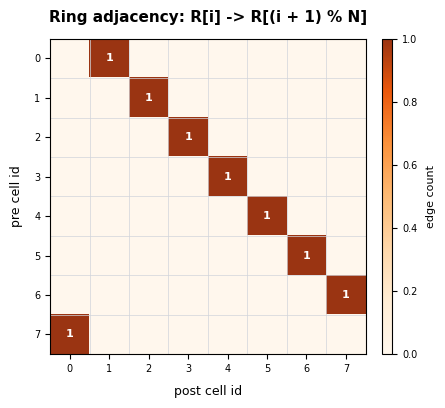

R first spike times ms: [5.800000000000001, 14.850000000000001, 23.900000000000002, 32.95, 42.0, 51.050000000000004, 60.1, 69.15]
R spike counts: [2, 1, 1, 1, 1, 1, 1, 1]
first spike times monotonic: True


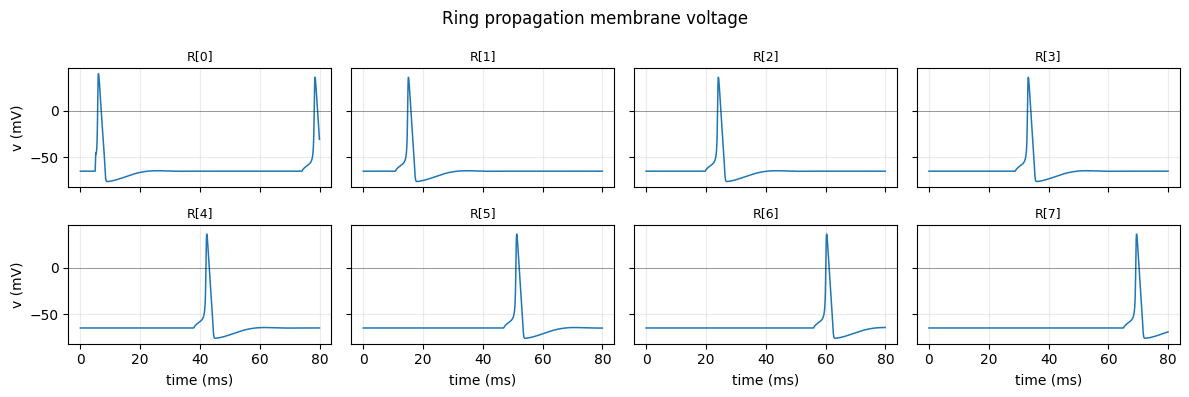

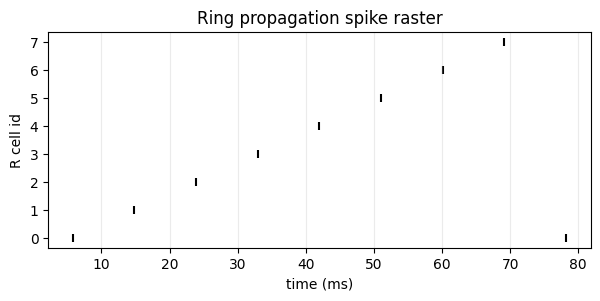

  R.g_exp shape: (1600, 8)
  R.g_exp max uS: 0.0019506198240566654


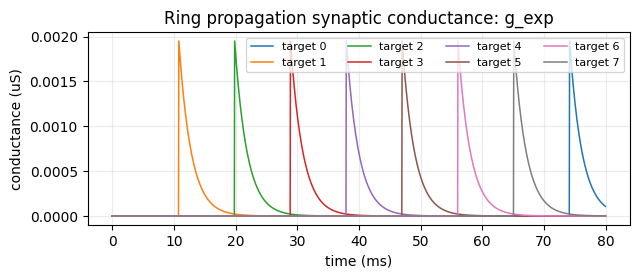

{'g_exp': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.12832279e-04, 1.97767829e-18, 1.82531649e-16, ...,
         1.43511191e-10, 1.32454982e-08, 1.22250552e-06],
        [1.10046440e-04, 1.92884924e-18, 1.78024926e-16, ...,
         1.39967887e-10, 1.29184657e-08, 1.19232175e-06],
        [1.07329384e-04, 1.88122578e-18, 1.73629475e-16, ...,
         1.36512068e-10, 1.25995077e-08, 1.16288322e-06]], shape=(1600, 8))}

In [21]:
ring_size = 8
ring_external_amplitudes = np.zeros(ring_size, dtype=float)
ring_external_amplitudes[0] = 2.0

ring_cell = Cell(
    build_demo_morphology(),
    cv_policy=CVPerBranch(),
    pop_size=(ring_size,),
    V_init=-65.0 * u.mV,
    V_th=0.0 * u.mV,
    solver="staggered",
    name="ring_cell",
)
add_hh_membrane(ring_cell)
ring_cell.place(
    at("soma", 0.5),
    mech.CurrentClamp(
        delay=u.Quantity(np.full(ring_size, 5.0), u.ms),
        durations=0.2 * u.ms,
        amplitudes=u.Quantity(ring_external_amplitudes, u.nA),
    ),
)
ring_cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
ring_cell.place(at("soma", 0.5), mech.MechanismProbe(name="g_exp", mechanism="exp", field="g"))
ring_cell.place(
    at("soma", 0.5),
    mech.Synapse(
        "ExpSyn",
        tau=2.0 * u.ms,
        e=0.0 * u.mV,
        weight=1.0 * u.uS,
        name="exp",
    ),
)

ring_net = braincell.Network(name="ring_propagation_demo")
ring_net.add_population("R", ring_cell)
ring_pairs = [(idx, (idx + 1) % ring_size) for idx in range(ring_size)]
ring_edges = ring_net.add_edges(
    name="ring_edges",
    pre="R",
    post="R",
    method=braincell.network.pairs(ring_pairs),
)
ring_net.add_projection(
    name="ring_exp",
    edges="ring_edges",
    synapse="exp",
    weight=0.002 * u.uS,
    delay=5.0 * u.ms,
)

ring_net.reset_state()
ring_result = ring_net.run(
    dt=0.05 * u.ms,
    duration=80.0 * u.ms,
    event_backend="scatter",
    spike_recording="population",
)
ring_voltage = trace_to_2d(ring_result.traces["R"]["v"], u.mV)
if np.isnan(ring_voltage).any():
    raise RuntimeError("Ring propagation demo produced NaN voltage values.")

print(ring_net)
edge_table(ring_edges)
plot_adjacency(ring_edges, n_pre=ring_size, n_post=ring_size, title="Ring adjacency: R[i] -> R[(i + 1) % N]")
ring_first, ring_counts = first_spike_times(ring_result, "R")
finite_first = [value for value in ring_first if value is not None]
print("first spike times monotonic:", finite_first == sorted(finite_first))
plot_voltage_small_multiples(ring_result, "R", title="Ring propagation membrane voltage")
plot_spike_raster(ring_result, "R", title="Ring propagation spike raster")
plot_conductance(ring_result, "R", title="Ring propagation synaptic conductance")


## 6. Direct `Connection`: the lower-level contact table

`Connection` bypasses `EdgeSet` and `Projection`.  Use it when you already have the final contact table.

This is lower-level but useful for debugging or importing connectivity from another source.

Connection: E -> I, synapse='exp'
  n_contact: 3
  contact_id | pre | post | synapse_index | weight_uS | delay_ms
           0 |   0 |    1 |             0 |     0.001 |      0.0
           1 |   1 |    1 |             1 |    0.0015 |      0.1
           2 |   1 |    0 |             0 |    0.0012 |      0.2
Network(name='direct_connection_demo', populations=2, edge_sets=0, projections=0, connections=1)
  populations:
    E: size=2, cell=Cell, initialized=False
    I: size=2, cell=Cell, initialized=False
  edge_sets:
    <none>
  projections:
    <none>
  direct connections:
    [0]: E -> I, synapse='exp', n_contact=3


direct Connection contact table
  result.time shape: (300,)
  trace keys: {'E': ('v',), 'I': ('g_exp', 'v')}
  spike shapes: {'E': (300, 2), 'I': (300, 2)}
  E.v range mV: (-75.45278351766282, 20.56757353643302)


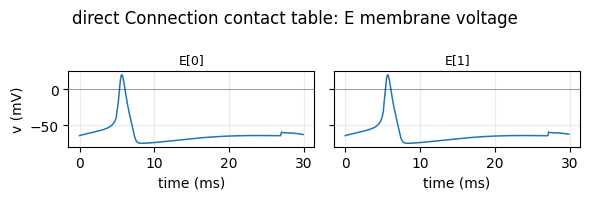

E first spike times ms: [5.4, 5.4]
E spike counts: [1, 1]


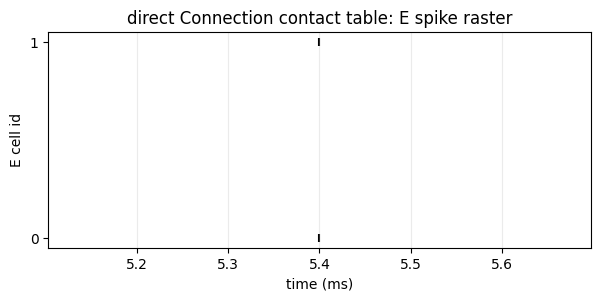

  I.v range mV: (-75.18934986650045, 20.01386284193269)


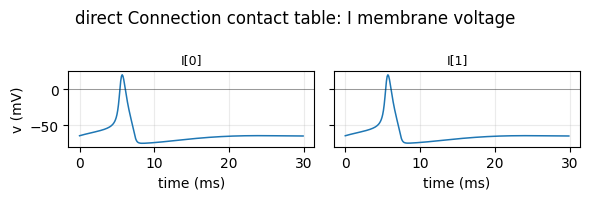

I first spike times ms: [5.4, 5.4]
I spike counts: [1, 1]


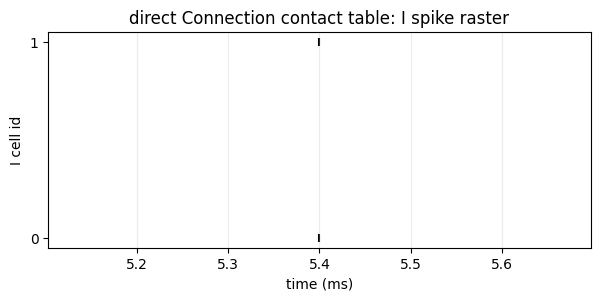

  I.g_exp shape: (300, 2, 2)
  I.g_exp max uS: 0.001426844136751071


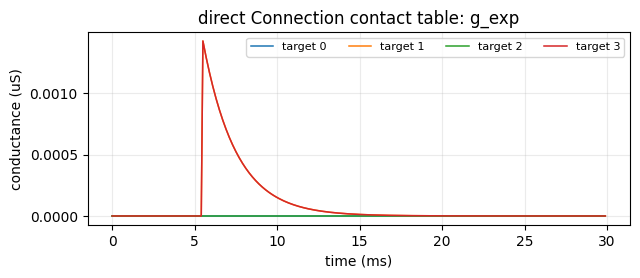

In [22]:
pre = build_pre_cell(size=2)
post = build_post_cell(size=2, two_targets=True)

conn_net = braincell.Network(name="direct_connection_demo")
conn_net.add_population("E", pre)
conn_net.add_population("I", post)

conn = braincell.network.Connection(
    pre_population="E",
    post_population="I",
    pre_index=[0, 1, 1],
    post_index=[1, 1, 0],
    synapse="exp",
    synapse_index=[0, 1, 0],
    weight=[0.0010, 0.0015, 0.0012] * u.uS,
    delay=[0.0, 0.1, 0.2] * u.ms,
)
connection_table(conn)
conn_net.add_connection(conn)
print(conn_net)

result = run_and_plot(conn_net, title="direct Connection contact table")


## 7. Reading `NetworkRunResult`

`Network.run(...)` returns:

- `time`: step times,
- `traces`: nested mapping `population_name -> probe_name -> trace`,
- `spikes`: spike traces controlled by `spike_recording`.

`spike_recording="full"` records full cell spike buffers.  `"population"` records the cell-level spike vector used by event delivery.  `"none"` omits spike traces while still delivering events internally.

In [23]:
pre = build_pre_cell(size=2)
post = build_post_cell(size=2)
result_net = braincell.Network(name="result_demo")
result_net.add_population("E", pre)
result_net.add_population("I", post)
result_net.add_edges(name="E_to_I", pre="E", post="I", method=braincell.network.all_pairs())
result_net.add_projection(name="E_to_I_exp", edges="E_to_I", synapse="exp", weight=0.001 * u.uS)

full = result_net.run(dt=0.1 * u.ms, duration=30.0 * u.ms, event_backend="scatter", spike_recording="full")
print("full spike shapes:", {name: np.asarray(value).shape for name, value in full.spikes.items()})
print("trace keys:", {name: tuple(traces) for name, traces in full.traces.items()})
print("E population spike counts:", np.asarray(full.spikes["E"]).reshape((full.spikes["E"].shape[0], -1)).sum(axis=0).astype(int))

result_net.reset_state()

population_only = result_net.run(dt=0.1 * u.ms, duration=30.0 * u.ms, event_backend="scatter", spike_recording="population")
print("population spike shapes:", {name: np.asarray(value).shape for name, value in population_only.spikes.items()})

result_net.reset_state()

none = result_net.run(dt=0.1 * u.ms, duration=30.0 * u.ms, event_backend="scatter", spike_recording="none")
print("none spikes:", none.spikes)


full spike shapes: {'E': (300, 2, 2), 'I': (300, 2, 2)}
trace keys: {'E': ('v',), 'I': ('g_exp', 'v')}
E population spike counts: [1 1 1 1]


population spike shapes: {'E': (300, 2), 'I': (300, 2)}


none spikes: {}


## 8. Runtime options: backend and delay quantization

For portable tutorials, `event_backend="scatter"` is explicit and predictable.  `event_backend="auto"` can use `brainevent.coomv` when available.

Delay values are converted to integer steps:

- `delay_quantization="ceil"`: default; never delivers earlier than the requested delay,
- `"floor"`: can deliver earlier for non-grid delays,
- `"strict"`: requires every delay to be an integer multiple of `dt`.

In [24]:
pre = build_pre_cell(size=1)
post = build_post_cell(size=2)
delay_net = braincell.Network(name="delay_quantization_demo")
delay_net.add_population("E", pre)
delay_net.add_population("I", post)
delay_net.add_connection(
    braincell.network.Connection(
        "E",
        "I",
        [0],
        [1],
        "exp",
        weight=0.002 * u.uS,
        delay=0.15 * u.ms,
    )
)

ceil_result = delay_net.run(
    dt=0.1 * u.ms,
    duration=8.0 * u.ms,
    event_backend="scatter",
    delay_quantization="ceil",
    spike_recording="population",
)
ceil_g = trace_to_2d(ceil_result.traces["I"]["g_exp"], u.uS)[:, 1]
ceil_positive = np.flatnonzero(ceil_g > 0.0)
print("ceil first positive conductance step:", None if ceil_positive.size == 0 else int(ceil_positive[0]))

delay_net.reset_state()

floor_result = delay_net.run(
    dt=0.1 * u.ms,
    duration=8.0 * u.ms,
    event_backend="scatter",
    delay_quantization="floor",
    spike_recording="population",
)
floor_g = trace_to_2d(floor_result.traces["I"]["g_exp"], u.uS)[:, 1]
floor_positive = np.flatnonzero(floor_g > 0.0)
print("floor first positive conductance step:", None if floor_positive.size == 0 else int(floor_positive[0]))


ceil first positive conductance step: 56


floor first positive conductance step: None
